# LSTMs with PyTorch — Sine Wave Prediction (SOLUTION)

LSTM adds a **cell state** `c_t` (long-term memory) and three gates to the vanilla RNN, solving the vanishing gradient problem.

Primary task: **time-series regression** on a synthetic sine wave.

## Key Concept: LSTM Gates — Gated Memory

The LSTM (Hochreiter & Schmidhuber, 1997) introduces a **cell state** `c_t`
— a highway along which gradients can flow across many timesteps with
minimal distortion.

**Four computations per timestep** (all using `[h_{t-1}, x_t]` as input):

| Gate | Formula | Role |
|------|---------|------|
| Forget | `f = σ(W_f·[h,x] + b_f)` | What fraction of `c_{t-1}` to *keep* |
| Input  | `i = σ(W_i·[h,x] + b_i)` | How much *new* information to write |
| Cell update | `g = tanh(W_g·[h,x] + b_g)` | *What* new information to write |
| Output | `o = σ(W_o·[h,x] + b_o)` | What to expose as hidden state |

**State updates:**
```
c_t  =  f ⊙ c_{t-1}  +  i ⊙ g       ← cell state (long-term memory)
h_t  =  o ⊙ tanh(c_t)               ← hidden state (short-term/output)
```

**Why does this solve vanishing gradients?**
When `f ≈ 1` (forget gate open), `c_t ≈ c_{t-1} + i ⊙ g` — the gradient
∂c_t/∂c_{t-1} ≈ 1 regardless of how many timesteps separate two events.
This "gradient highway" lets the LSTM remember things from hundreds of
steps ago without the exponential decay that cripples vanilla RNNs.

> 📖 [Colah — Understanding LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)

## Step 1: Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

device: mps


## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop stays simple.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)   # pairs inputs with labels
loader  = DataLoader(dataset,
                     batch_size=64,
                     shuffle=True)           # reshuffles every epoch

for Xb, yb in loader:                       # Xb: (64, ...) one mini-batch
    ...
```

Key parameters:
- `batch_size` — number of samples per gradient update
- `shuffle=True` — randomise order each epoch (always use for training)
- `num_workers` — background processes for loading (set to 2-4 on most machines)

> 📖 [PyTorch — Writing a Custom Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)


## Step 2: Generate the Sine Wave Dataset

In [2]:
t    = np.linspace(0, 4 * np.pi, 200)  # 200 evenly spaced steps over two full cycles
data = np.sin(t).astype(np.float32)    # (200,) float32; values in [-1.0, 1.0]
print(f'data shape: {data.shape}  min={data.min():.2f}  max={data.max():.2f}')

data shape: (200,)  min=-1.00  max=1.00


## Step 3: Create Sliding Window Sequences

In [3]:
def create_sequences(data, seq_len=20):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len].reshape(seq_len, 1))  # (20, 1): 20 timesteps, 1 feature
        ys.append(data[i+seq_len].reshape(1))              # (1,): scalar target value
    return torch.tensor(np.array(xs)), torch.tensor(np.array(ys))

X, y = create_sequences(data, seq_len=20)
# X: (180, 20, 1) — 180 sliding windows, each 20 timesteps with 1 feature per step
# y: (180, 1)     — one target (the 21st value) per window
print('X:', X.shape, '  y:', y.shape)

X: torch.Size([180, 20, 1])   y: torch.Size([180, 1])


## Step 4: Train/Test Split

In [4]:
split = int(0.8 * len(X))  # 144 train / 36 test
X_train, X_test = X[:split].to(device), X[split:].to(device)  # (144,20,1) / (36,20,1)
y_train, y_test = y[:split].to(device), y[split:].to(device)  # (144,1)    / (36,1)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: torch.Size([144, 20, 1])  Test: torch.Size([36, 20, 1])


## Step 5: Define the LSTM Model

`nn.LSTM` returns `(output, (h_n, c_n))` — the extra `c_n` (cell state) is the key difference from `nn.RNN`.

In [5]:
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        # LSTM: input_size=1 (one value per timestep), hidden_size=32
        # unlike nn.RNN, returns (output, (h_n, c_n)) — cell state c_n is the extra piece
        # output: (B, seq_len, 32)  h_n and c_n: each (num_layers, B, 32)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # We only need the last timestep's output for regression: 32 features → 1 value
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):                    # x: (B, 20, 1)
        out, _ = self.lstm(x)                # out: (B, 20, 32)  _=(h_n,c_n) discarded
        return self.fc(out[:, -1, :])        # out[:,-1,:]: (B,32) → fc → (B,1)

model = SineLSTM().to(device)
print(model)

SineLSTM(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Concept Check: LSTM Architecture — Answers

**Q1.** `nn.LSTM` returns `(output, (h_n, c_n))`.
`nn.RNN` returns `(output, h_n)`.
What is `c_n` and why doesn't `nn.RNN` have it?

**→** `c_n` is the final **cell state** — the long-term memory vector.
`nn.RNN` has no equivalent because its recurrence is stateless beyond the
hidden vector: `h_t = tanh(W_h h_{t-1} + W_x x_t)`. There is no separate
cell state in the RNN formulation.

**Q2.** In `SineLSTM.forward` we use `out[:, -1, :]` — the last timestep's
output. An alternative is `h_n[-1]` (the final hidden state from the last
layer). Are these always identical for LSTM? Under what conditions might
they differ?

**→** For `nn.LSTM` with `batch_first=True`: `out[:, -1, :]` is the
last-timestep output of the *last* layer — same as `h_n[-1]`. They are
always identical. The distinction matters for bidirectional LSTMs where
`h_n` contains the final hidden states from both directions, while `out`
contains all timesteps for the forward direction only.

**Q3.** With `num_layers=2`, the second LSTM layer's input is the output
sequence of the first layer. What shape does this input have, and why is
stacking layers beneficial?

**→** The second layer receives `output` from layer 1: shape
`(batch_size, seq_len, hidden_size)` — a full sequence of 32-d vectors.
Stacking layers allows the network to learn increasingly abstract temporal
features: layer 1 might capture short-range patterns; layer 2 can relate
those patterns across longer timescales.

## Step 6: Training Loop

In [6]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
criterion    = nn.MSELoss()   # regression: mean((pred - target)²) over the batch
optimizer    = optim.Adam(model.parameters(), lr=0.001)
epoch_losses = []

for epoch in range(100):
    model.train()
    total = 0
    for Xb, yb in train_loader:
        # For MPS/CUDA: data must be on the same device as model weights.
        # Both are already on `device` here because we called .to(device) at dataset time.
        pred = model(Xb)            # Xb: (16,20,1) → pred: (16,1) via LSTM + linear

        # MSELoss averages squared differences element-wise over all (B, 1) values.
        loss = criterion(pred, yb)  # yb: (16,1)

        optimizer.zero_grad()       # accumulation prevention — reset before backward
        loss.backward()             # BPTT through 20 timesteps; LSTM gates get gradients too
        optimizer.step()

        total += loss.item()
    avg = total / len(train_loader)
    epoch_losses.append(avg)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Loss: {avg:.6f}')


Epoch   0 | Loss: 0.507678


Epoch  10 | Loss: 0.022861


Epoch  20 | Loss: 0.000508


Epoch  30 | Loss: 0.000035


Epoch  40 | Loss: 0.000022


Epoch  50 | Loss: 0.000018


Epoch  60 | Loss: 0.000020


Epoch  70 | Loss: 0.000014


Epoch  80 | Loss: 0.000009


Epoch  90 | Loss: 0.000007


## Step 7: Evaluate on Test Set

In [7]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
print(f'Test MSE: {test_loss.item():.6f}')

Test MSE: 0.000007


## Step 8: Visualize Predictions vs Actuals

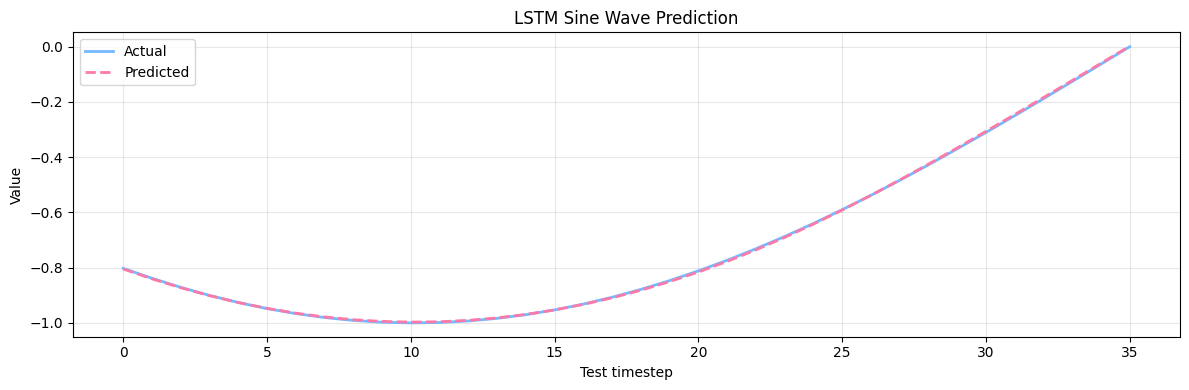

In [8]:
model.eval()
with torch.no_grad():
    preds   = model(X_test).cpu().squeeze().numpy()
    actuals = y_test.cpu().squeeze().numpy()

plt.figure(figsize=(12, 4))
plt.plot(actuals, label='Actual',    linewidth=2, color='#74b9ff')
plt.plot(preds,   label='Predicted', linewidth=2, linestyle='--', color='#fd79a8')
plt.legend()
plt.title('LSTM Sine Wave Prediction')
plt.xlabel('Test timestep')
plt.ylabel('Value')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Compare LSTM vs RNN

LSTM test MSE: 0.000007
RNN  test MSE: 0.000052


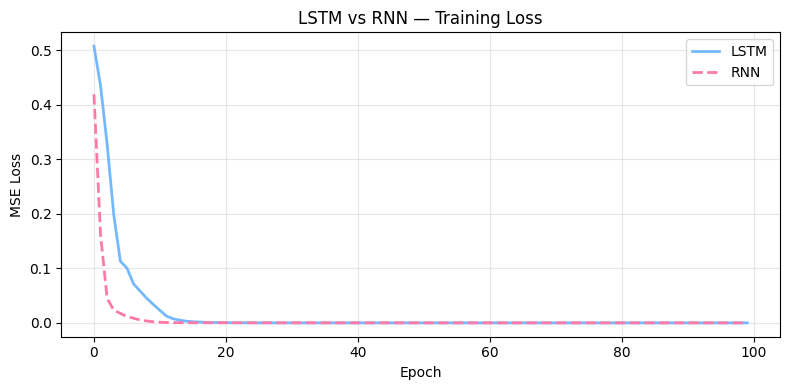

In [9]:
class SineRNN(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.RNN returns (output, h_n) — no cell state c_n, unlike LSTM
        # same interface otherwise: output (B, 20, 32), same fc
        self.rnn = nn.RNN(1, 32, 2, batch_first=True)
        self.fc  = nn.Linear(32, 1)
    def forward(self, x):              # x: (B, 20, 1)
        out, _ = self.rnn(x)           # out: (B, 20, 32)
        return self.fc(out[:, -1, :])  # → (B, 1)

rnn_model = SineRNN().to(device)
opt_rnn   = optim.Adam(rnn_model.parameters(), lr=0.001)
rnn_losses = []

for epoch in range(100):
    rnn_model.train()
    total = 0
    for Xb, yb in train_loader:
        pred = rnn_model(Xb)
        loss = criterion(pred, yb)
        opt_rnn.zero_grad()
        loss.backward()
        opt_rnn.step()
        total += loss.item()
    rnn_losses.append(total / len(train_loader))

rnn_model.eval()
with torch.no_grad():
    rnn_test_loss = criterion(rnn_model(X_test), y_test)

print(f'LSTM test MSE: {test_loss.item():.6f}')
print(f'RNN  test MSE: {rnn_test_loss.item():.6f}')

plt.figure(figsize=(8, 4))
plt.plot(epoch_losses, label='LSTM', color='#74b9ff', linewidth=2)
plt.plot(rnn_losses,   label='RNN',  color='#fd79a8', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM vs RNN — Training Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Concept Check: Sequence Models — LSTM vs RNN vs What's Next — Answers

**Q1.** You observed LSTM outperforms RNN on this 20-step sine wave.
How do you expect the performance gap to change on a 200-step sequence?
On a 5-step sequence? Why?

**→** - **200 steps**: the gap widens significantly. The cell state's gradient
  highway becomes essential; RNN gradients from step 1 are virtually zero.
- **5 steps**: the gap shrinks. With only 5 steps, vanilla RNN can still
  backpropagate usable gradients — its weakness only shows at long range.

**Q2.** Both RNN and LSTM process tokens *sequentially* — each step
depends on the previous hidden state. Name the key computational
bottleneck this creates, and explain in one sentence how the Transformer
architecture (next lesson) removes it.

**→** The bottleneck: `h_t` depends on `h_{t-1}`, so timesteps must be
computed *serially* regardless of batch size — GPUs cannot parallelise across
sequence length.
**Transformer**: replaces recurrence with self-attention, which computes
relationships between all positions simultaneously as a single matrix
operation — fully parallelisable over sequence length.

**Q3.** The LSTM cell state solves vanishing *but not* exploding gradients.
Why is exploding still possible in LSTMs, and what is the standard fix?

**→** The cell-state update `c_t = f ⊙ c_{t-1} + i ⊙ g` can still produce
growing gradients if `f > 1` (impossible — sigmoid output is in `(0,1)`) ...
Actually `f ∈ (0,1)` prevents cell-state explosions. However, the hidden
state `h_t = o ⊙ tanh(c_t)` and the weight matrices `W` can still produce
large gradients through the gate computations themselves.
Standard fix: **gradient clipping** (same as for RNNs).

## Step 10: Visualize the LSTM Cell Architecture

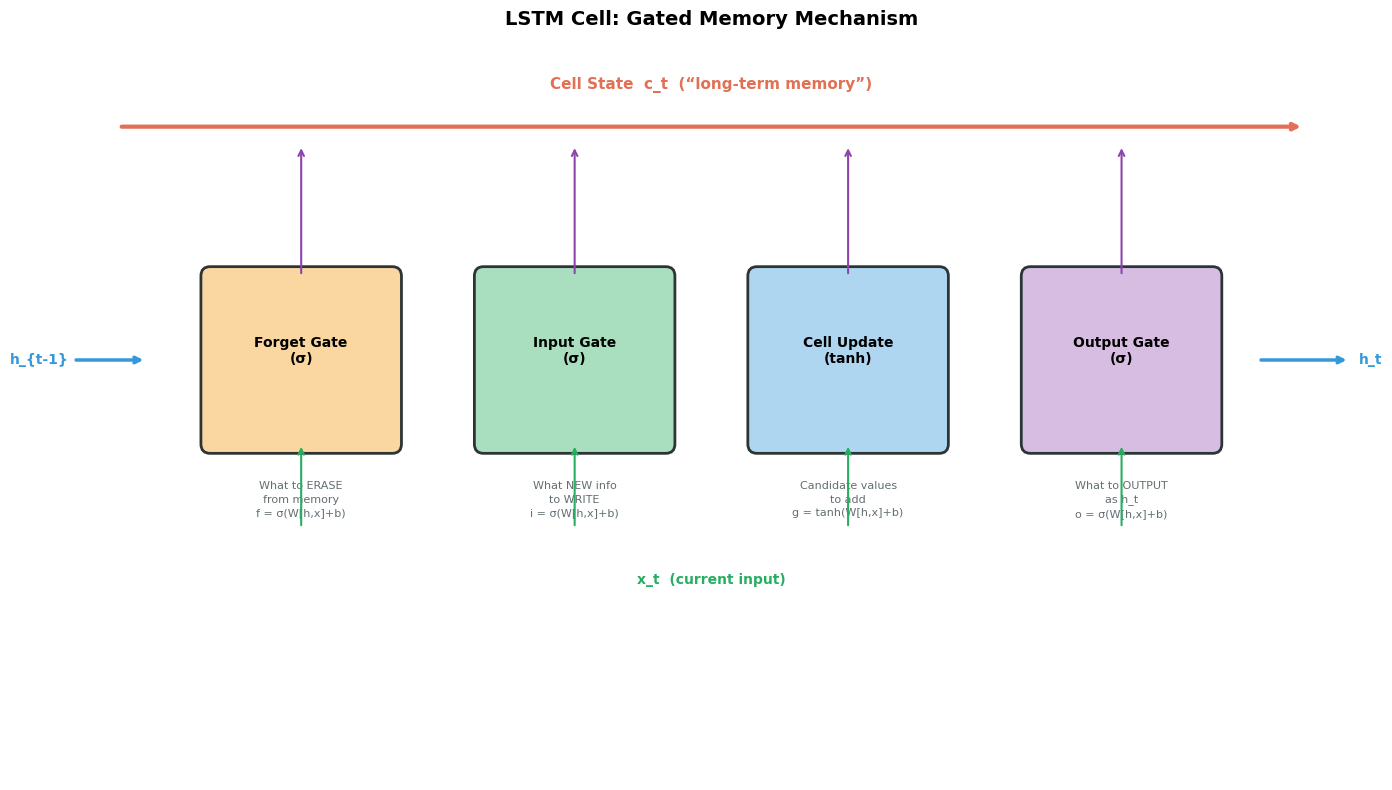

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('LSTM Cell: Gated Memory Mechanism', fontsize=14, fontweight='bold')

# Cell state highway (top)
ax.annotate('', xy=(13.5, 7.0), xytext=(0.5, 7.0),
            arrowprops=dict(arrowstyle='->', color='#e17055', lw=3))
ax.text(7, 7.4, 'Cell State  c_t  (“long-term memory”)', ha='center',
        fontsize=11, color='#e17055', fontweight='bold')

gates = [
    (2.5,  'Forget Gate\n(σ)', '#FAD7A0',
     'What to ERASE\nfrom memory\nf = σ(W[h,x]+b)'),
    (5.5,  'Input Gate\n(σ)', '#A9DFBF',
     'What NEW info\nto WRITE\ni = σ(W[h,x]+b)'),
    (8.5,  'Cell Update\n(tanh)', '#AED6F1',
     'Candidate values\nto add\ng = tanh(W[h,x]+b)'),
    (11.5, 'Output Gate\n(σ)', '#D7BDE2',
     'What to OUTPUT\nas h_t\no = σ(W[h,x]+b)'),
]
for x, label, color, desc in gates:
    rect = mpatches.FancyBboxPatch((x - 1.0, 3.6), 2.0, 1.8,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#2d3436', lw=2)
    ax.add_patch(rect)
    ax.text(x, 4.6, label, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x, 3.2, desc, ha='center', va='top', fontsize=8, color='#636e72', linespacing=1.4)
    ax.annotate('', xy=(x, 6.8), xytext=(x, 5.4),
                arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.5))

# h_{t-1} input
ax.annotate('', xy=(0.8, 4.5), xytext=(0.0, 4.5),
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=2.5))
ax.text(-0.05, 4.5, 'h_{t-1}', ha='right', va='center', fontsize=10,
        color='#3498db', fontweight='bold')

# x_t inputs
ax.text(7, 2.1, 'x_t  (current input)', ha='center', fontsize=10,
        color='#27ae60', fontweight='bold')
for gx in [2.5, 5.5, 8.5, 11.5]:
    ax.annotate('', xy=(gx, 3.6), xytext=(gx, 2.7),
                arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

# h_t output
ax.annotate('', xy=(14.0, 4.5), xytext=(13.0, 4.5),
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=2.5))
ax.text(14.1, 4.5, 'h_t', ha='left', va='center', fontsize=10,
        color='#3498db', fontweight='bold')

plt.tight_layout()
plt.show()


## Bonus: Multi-layer LSTM with Dropout

In [11]:
class SineLSTMDeep(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, num_layers=3, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

deep = SineLSTMDeep().to(device)
opt_deep = optim.Adam(deep.parameters(), lr=0.001)
deep_losses = []

for epoch in range(100):
    deep.train()
    total = 0
    for Xb, yb in train_loader:
        pred = deep(Xb)
        loss = criterion(pred, yb)
        opt_deep.zero_grad()
        loss.backward()
        opt_deep.step()
        total += loss.item()
    deep_losses.append(total / len(train_loader))

deep.eval()
with torch.no_grad():
    deep_loss = criterion(deep(X_test), y_test)
print(f'Deep LSTM (3-layer, dropout=0.2) test MSE: {deep_loss.item():.6f}')

Deep LSTM (3-layer, dropout=0.2) test MSE: 0.406859
